In [15]:
# Install the package pmdarima
# !pip install pmdarima --quiet

In [16]:
import os
# import datetime
from datetime import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm_notebook
from itertools import product

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from typing import Union

from matplotlib.pylab import rcParams

from statsmodels.tsa.stattools import adfuller
import pmdarima as pm


# import warnings
# warnings.filterwarnings('ignore')
%matplotlib inline
# use daily averages

In [18]:
# read in the merged station datasets
# Station1-Simulated-cleaned-merged-data.csv

path = "../../datasets/Merged-Cleaned-Simulated-Data/"

# path = "../../datasets/TX-Data/soil_station_cleanedup/"

dfs = {}
for index in range(0, 6) :
    filename=path+'Station' + str(index + 1) + '-Simulated-cleaned-merged-data.csv'
#     filename=path+'SM_' + str(index + 1) + '_filled.dat'
    print(filename)
    df = pd.read_csv(filename, sep=",", parse_dates=["Date"], index_col="Date")
    dfs['Station' + str(index + 1)] = df

dfs['Station1']

../../datasets/Merged-Cleaned-Simulated-Data/Station1-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station2-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station3-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station4-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station5-Simulated-cleaned-merged-data.csv
../../datasets/Merged-Cleaned-Simulated-Data/Station6-Simulated-cleaned-merged-data.csv


,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Tair,RH,Windspeed,Winddirection,Srad,Ppt,Latitude,Longitude
Date,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,0.139,0.178,0.148,0.152,2.81,4.40,5.77,10.57,-1.090,81.50,1.052,52.27,0.63,0.0,30.3989,-98.6105
2015-01-01 01:00:00,0.139,0.178,0.148,0.152,2.86,4.38,5.71,10.51,-1.038,81.70,0.959,46.71,0.62,0.0,30.3989,-98.6105
2015-01-01 02:00:00,0.139,0.178,0.148,0.152,2.89,4.35,5.66,10.47,-0.981,82.00,1.062,52.04,0.60,0.0,30.3989,-98.6105
2015-01-01 03:00:00,0.139,0.178,0.148,0.152,2.90,4.33,5.62,10.41,-0.814,81.90,0.887,58.91,0.64,0.0,30.3989,-98.6105
2015-01-01 04:00:00,0.139,0.178,0.148,0.152,2.96,4.32,5.59,10.36,-0.805,90.00,0.828,16.55,0.20,0.0,30.3989,-98.6105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-08-31 20:00:00,0.097,0.104,0.104,0.106,34.60,34.71,33.68,29.86,29.100,60.19,0.610,197.10,0.00,0.0,30.3989,-98.6105
2021-08-31 21:00:00,0.097,0.103,0.104,0.106,33.58,34.07,33.50,29.95,28.070,62.28,0.510,199.60,0.00,0.0,30.3989,-98.6105
2021-08-31 22:00:00,0.096,0.103,0.103,0.106,32.75,33.46,33.23,30.03,27.730,63.98,1.417,192.60,0.00,0.0,30.3989,-98.6105


In [45]:
station = "Station1"
SWC = "SWC_50"

In [53]:
st1_swc50_2 = dfs[station][[SWC]]

In [54]:
st1_swc50_2

,SWC_20
Date,
2015-01-01 00:00:00,0.271
2015-01-01 01:00:00,0.271
2015-01-01 02:00:00,0.270
2015-01-01 03:00:00,0.270
2015-01-01 04:00:00,0.270
...,...
2021-08-31 20:00:00,0.187
2021-08-31 21:00:00,0.187
2021-08-31 22:00:00,0.187


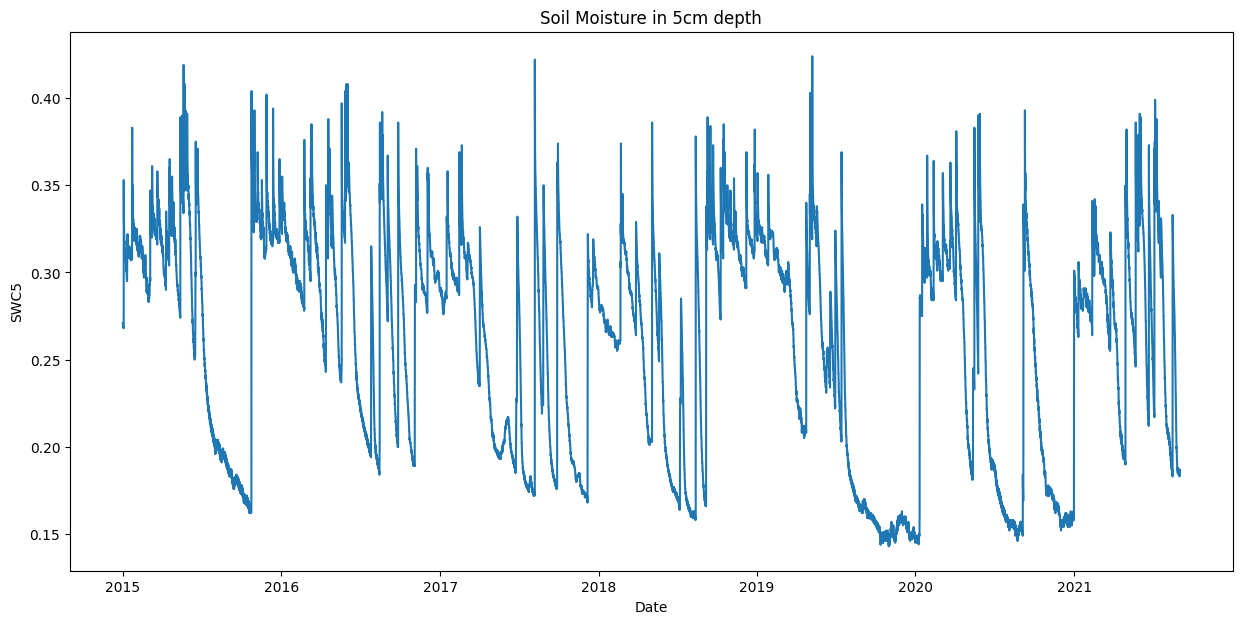

In [55]:
plt.figure(figsize=(15,7))
plt.title("Soil Moisture in 5cm depth")
plt.xlabel('Date')
plt.ylabel('SWC5')
plt.plot(st1_swc50_2)
plt.show()

# Augmented Dickey–Fuller Test


In [56]:
#Augmented Dickey–Fuller test:

print('Results of Dickey Fuller Test:')

dftest = adfuller(st1_swc50_2, autolag='AIC')

dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])

for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
    
print(dfoutput)

Results of Dickey Fuller Test:
Test Statistic                -6.828379e+00
p-value                        1.921650e-09
#Lags Used                     1.700000e+01
Number of Observations Used    5.834700e+04
Critical Value (1%)           -3.430462e+00
Critical Value (5%)           -2.861590e+00
Critical Value (10%)          -2.566796e+00
dtype: float64


In [57]:
print(len(st1_swc50["2015":"2015"]))
print(len(st1_swc50["2016":"2016"]))
print(len(st1_swc50["2017":"2017"]))
print(len(st1_swc50["2018":"2018"]))
print(len(st1_swc50["2019":"2019"]))
# print(len(st1_swc50["2020":"2021"]))

8696
8772
8760
8760
8760


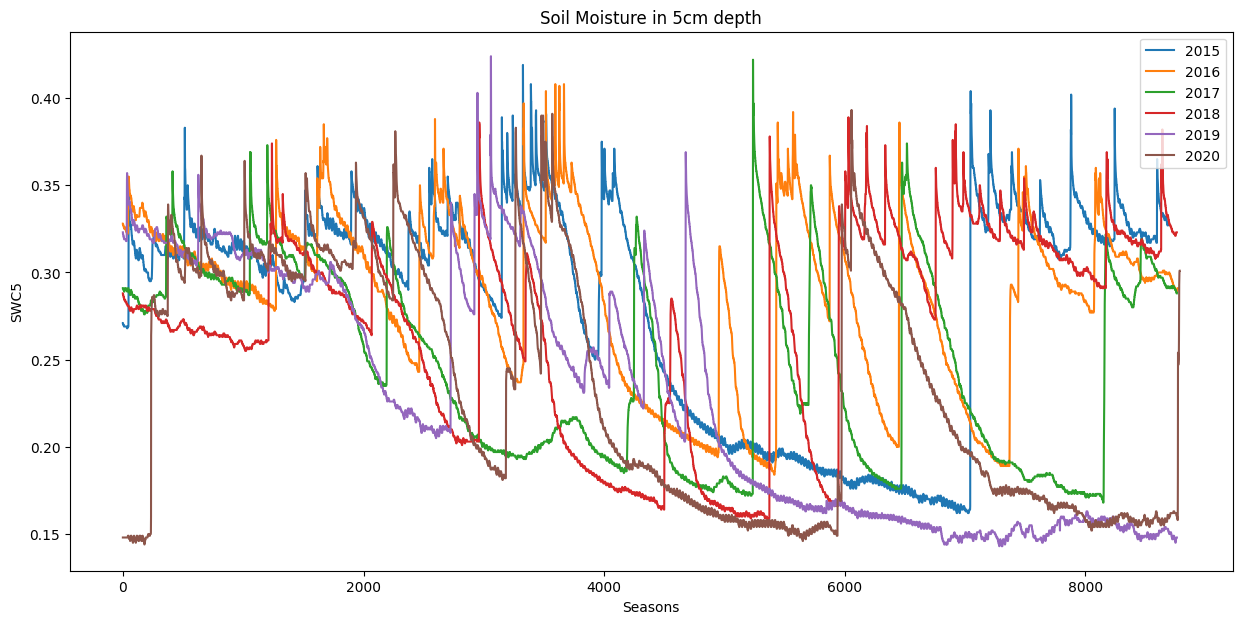

In [58]:
plt.figure(figsize=(15,7))
plt.title("Soil Moisture in 5cm depth")
plt.xlabel('Seasons')
plt.ylabel('SWC5')
plt.plot(st1_swc50["2015":"2015"].reset_index(drop=True), label="2015")
plt.plot(st1_swc50["2016":"2016"].reset_index(drop=True), label="2016")
plt.plot(st1_swc50["2017":"2017"].reset_index(drop=True), label="2017")
plt.plot(st1_swc50["2018":"2018"].reset_index(drop=True), label="2018")
plt.plot(st1_swc50["2019":"2019"].reset_index(drop=True), label="2019")
plt.plot(st1_swc50["2020":"2020"].reset_index(drop=True), label="2020")
plt.legend(loc='upper right')

plt.show()

# ARIMA Model Selection w/ Auto-ARIMA
Data is stationary

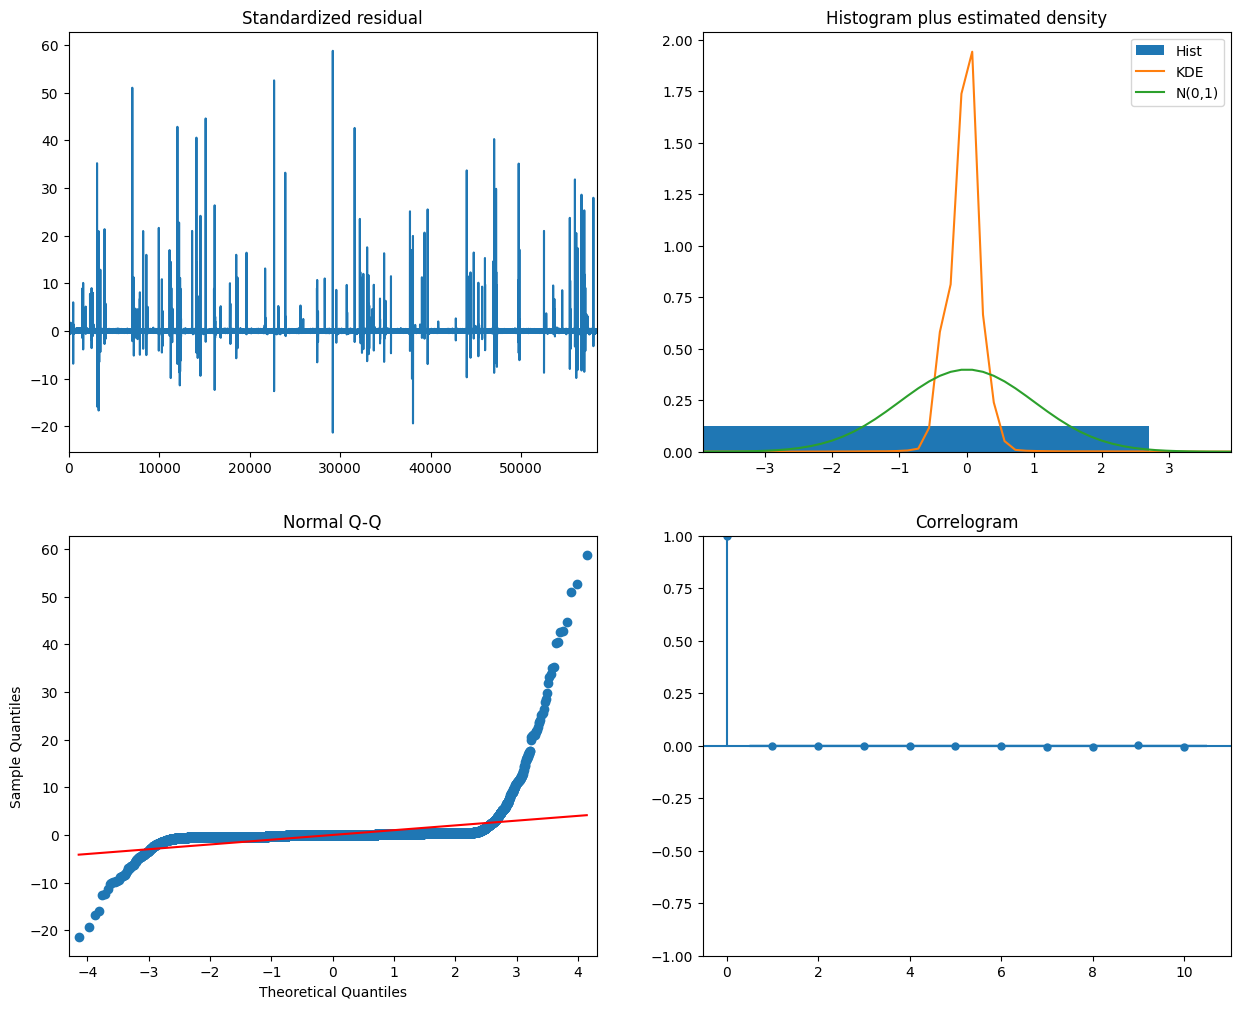

In [78]:
#Standard ARIMA Model
arima_model = pm.auto_arima(st1_swc50_2.reset_index(drop=True), 
                      start_p=1,
                      start_q=1,
                      test='adf', # use adftest to find optimal 'd'
                      max_p=24, max_q=24, # maximum p and q
                      m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                      d=None,# let model determine 'd'
                      seasonal=False, # No Seasonality for standard ARIMA
                      trace=False, #logs
                      error_action='warn', #shows errors ('ignore' silences these)
                      suppress_warnings=True,
                      stepwise=True)

arima_model.plot_diagnostics(figsize=(15,12))
plt.show()

In [102]:
fitted, confint = arima_model.predict(start="2015", end="2020", return_conf_int=True, dynamic=False)

fitted

58365    0.185656
58366    0.185608
58367    0.185570
58368    0.185551
58369    0.185530
58370    0.185510
58371    0.185490
58372    0.185470
58373    0.185451
58374    0.185432
dtype: float64

In [106]:
# index_of_fc = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods =7, freq='MS')
index_of_fc = st1_swc50_2["2015":"2020"].index

# make series for plotting purpose
fitted_series = pd.Series(fitted, index=index_of_fc)

fitted_series

Date
2015-01-01 00:00:00   NaN
2015-01-01 01:00:00   NaN
2015-01-01 02:00:00   NaN
2015-01-01 03:00:00   NaN
2015-01-01 04:00:00   NaN
                       ..
2020-12-31 19:00:00   NaN
2020-12-31 20:00:00   NaN
2020-12-31 21:00:00   NaN
2020-12-31 22:00:00   NaN
2020-12-31 23:00:00   NaN
Length: 52532, dtype: float64

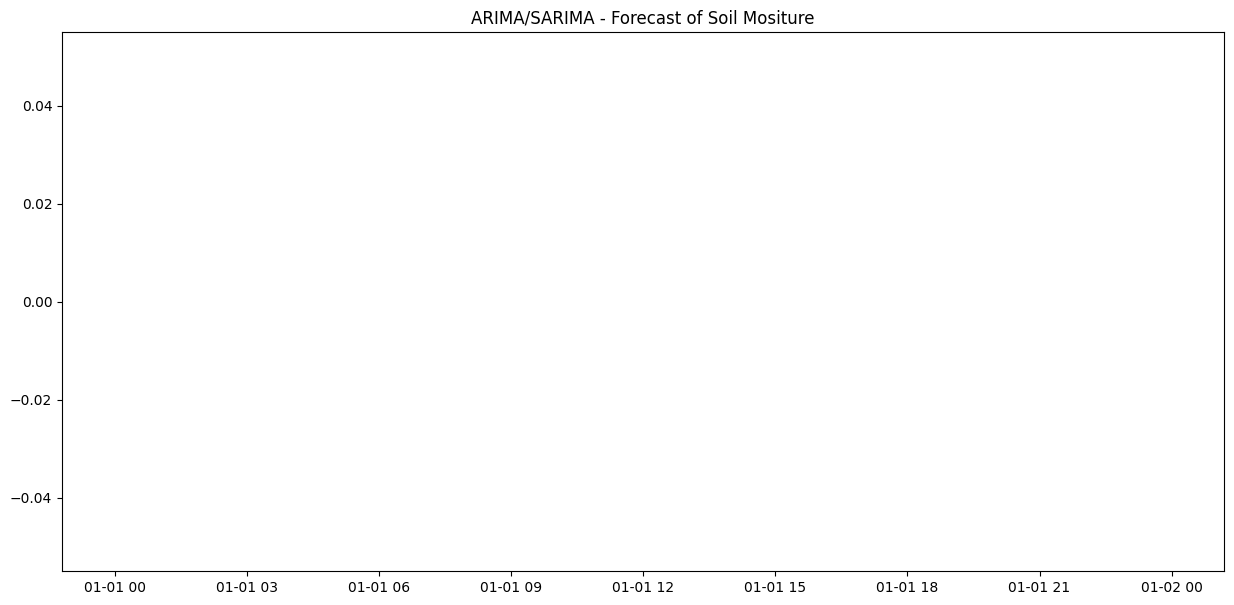

In [105]:
 # Plot
plt.figure(figsize=(15,7))
# plt.plot(st1_swc50_2, color='#1f76b4')
plt.plot(fitted_series, color='darkgreen')

plt.title("ARIMA/SARIMA - Forecast of Soil Mositure")
plt.show()

# Data Split